In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import poisson
from scipy.stats import norm
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
from scipy.special import lambertw

# Functions and Computations for Plots

In [3]:
def ComputeQ_Poiss(d,lam):

    if(d < np.exp(-lam)):
        return np.nan
    else:
        return 1+np.log(d)/lam

    
def ComputeQ_NegBinom(d,lam,r):

    if(d < np.power(1/(1+lam/r),r)):
        return np.nan
    else:
        return 1-r/lam * (1/np.power(d,1/r)-1)    
    
def ComputeQ_Approx(d,lam):

    if(d < 1-lam):
        return np.nan
    else:
        return  1-(1-d)/lam       
    

def calc_conf_int(alpha,lam,sample_size):

    return 1+ np.log(alpha)/(lam * sample_size)

In [4]:
lam=[0.1,0.5,1.0,2.0,10]
r=[0.1,1,2,3,5,7,10]


In [5]:

d_minus=np.arange(0.00001,1,0.00001)
s_Poiss =np.empty([len(lam),len(d_minus)])
s_NegBionom =np.empty([len(r),len(lam),len(d_minus)])

s_approx =np.empty([len(lam),len(d_minus)])
q_approx =np.empty([len(lam),len(d_minus)])

q_Poiss =np.empty([len(lam),len(d_minus)])
q_NegBionom =np.empty([len(r),len(lam),len(d_minus)])



In [6]:
t=0
for k in lam:
    j=0
    for i in d_minus:
        q_Poiss[t,j]=ComputeQ_Poiss(i,k)
        q_approx[t,j]=  ComputeQ_Approx(i,k)
        j+=1
    t+=1
l=0
for n in r:
    t=0
    for k in lam:
        j=0
        for i in d_minus:
            q_NegBionom[l,t,j]=ComputeQ_NegBinom(i,k,n)
            j+=1
        t+=1
    l+=1       
   

In [7]:
alpha=0.05
sample_size=[1e2,1e4,1e5,1e6,1e7,1e8,1e9]

conf =np.empty([len(lam),len(sample_size)])

t=0
for k in lam:
    j=0
    for i in sample_size:
        conf[t,j]=calc_conf_int(alpha,k,i)
        j+=1
    t+=1

In [8]:
q_Poiss_given=np.arange(0.00001,1,0.00001)

# a = lambda/r = lamda sigma_lam_rel ^2 and for pure volume variablity sigma_lam_rel =sigma_V_rel where sigma_V_rel is reltive colume variablity
a=np.array([0.01,0.1,0.2,0.3,0.4,0.5,1])



q_NB =np.empty([len(a),len(q_Poiss_given)])

for i,val in enumerate(a):
    q_NB[i,:]=1+ 1/val * (1-np.exp(val * (1-q_Poiss_given)))
               
q_NB[q_NB<0]=np.nan

In [9]:
lam_scan=np.arange(0.1,12,0.1)
q=np.arange(0,1.1,0.1)


derivative =np.empty([len(q),len(lam_scan)])
derivative_min=np.empty([len(q),1])

for i,v in enumerate(q):
    derivative[i,:]= np.exp(lam_scan *(1-v))/lam_scan
    derivative_min[i]=np.exp(1) * (1-v)
    
integral=(np.exp(lam_scan)-1)/lam_scan**2

# Plot

In [10]:
tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}
tickParams = {
    "xtick.top":True,
    "xtick.bottom":True,
    "xtick.direction": "in",
    "ytick.left":True,
    "ytick.right":True,
    "ytick.direction": "in",
}
spinesParams = {
    'axes.spines.right' : True,
    'axes.spines.top' : True
}
plt.rcParams.update(tex_fonts)
plt.rcParams.update(tickParams)
inchPerCm = 0.393701
goldenRatio = (1+np.sqrt(5))/2
figWidthCm = 17.9
figHeightCm = figWidthCm
#figHeightCm = figWidthCm*1.2

figWidthInches = figWidthCm*inchPerCm
figHeightInches = figHeightCm*inchPerCm


lw=1
marker_size=10
linestyle_True_Poiss='-'
lw2=1

In [12]:
colors=sns.color_palette("colorblind")

cmap_lambda = mpl.colormaps['Blues_r']
cmap_a = mpl.colormaps['OrRd']
cmap_q = mpl.colormaps['plasma']
colors_q=cmap_q(q)

In [13]:
colors_lambda=cmap_lambda(np.arange(0,1,1/5))
colors_a = cmap_a(0.2 + 0.8 * a/np.max(a)) #because lowest color is barley visible


In [14]:
fig_label_x_1=-0.2
fig_label_x_2=-0.15

fig_label_y_1=1
fig_label_y_2=1

/var/folders/w2/jt66jqzn6p7bsw4898xd2vn80000gn/T/ipykernel_60593/157796274.py:37: RuntimeWarning: divide by zero encountered in divide
  pl=ax[0,1].plot(1/(1-q),derivative_min,'gray',lw=2,label=r'$\frac{1}{1-q}$')
/Users/erikmaikranz/miniconda3/lib/python3.11/site-packages/matplotlib/text.py:1461: ComplexWarning: Casting complex values to real discards the imaginary part
  x = float(self.convert_xunits(x))
/Users/erikmaikranz/miniconda3/lib/python3.11/site-packages/matplotlib/text.py:894: ComplexWarning: Casting complex values to real discards the imaginary part
  x = float(self.convert_xunits(self._x))


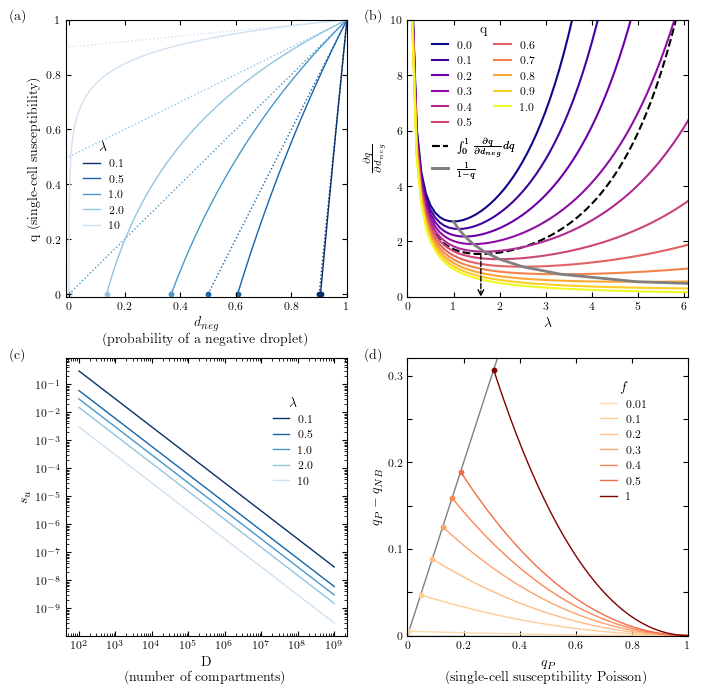

In [15]:
fig, ax = plt.subplots(2,2, figsize=(figWidthInches, figHeightInches))
#----------------------------Relate d_minus and q--------------------------------------------

for i in range(5):
    ax[0,0].plot(d_minus,q_Poiss[i,:],color=colors_lambda[i],linestyle=linestyle_True_Poiss,linewidth=lw,label=f'{lam[i]}')
    ax[0,0].scatter(np.exp(-lam[i]),0,color=colors_lambda[i],s=marker_size)

    ax[0,0].plot(d_minus,q_approx[i,:],color=colors_lambda[i],linestyle="dotted",linewidth=lw)
    ax[0,0].scatter(1-lam[i],0,color=colors_lambda[i],s=marker_size)

ax[0,0].set_yticks([0, 0.2, 0.4, 0.6,0.8,1], ['0', '0.2', '0.4', '0.6','0.8','1']) 
ax[0,0].set_xticks([0, 0.2, 0.4, 0.6,0.8,1], ['0', '0.2', '0.4', '0.6','0.8','1']) 

ax[0,0].set_ylim((-0.01,1))
ax[0,0].set_xlim((-0.01,1))

ax[0,0].set_xlabel('$d_{neg}$ \n (probability of a negative droplet)')
ax[0,0].set_ylabel('q (single-cell susceptibility)')


ax[0,0].legend(frameon=False,title='$\lambda$',loc='center left',bbox_to_anchor=(0.025,0.4),fancybox=True,handlelength=1.5,bbox_transform=ax[0,0].transAxes)


ax[0,0].text(fig_label_x_1, fig_label_y_1, '(a)', transform=ax[0,0].transAxes)


#-------------------------------------Optimal lambda ----------------------------------

int_handle=ax[0,1].plot(lam_scan,integral,'black',linestyle='--',label=r'$\int _0 ^1 \frac{\partial q}{\partial d_{neg}} dq$')
#int_handle=ax[0,1].plot(lam_scan,integral,'black',linestyle='--')

plt_handles=[]
for c,j in enumerate(derivative):
    foo=ax[0,1].plot(lam_scan,j,color=colors_q[c],label=f'{np.round(q[c],2)}')
    plt_handles.append(foo[0])
        
pl=ax[0,1].plot(1/(1-q),derivative_min,'gray',lw=2,label=r'$\frac{1}{1-q}$')
    
val=lambertw(-2/np.exp(1)**2)+2
y=(np.exp(val)-1)/val**2
ax[0,1].annotate("", xytext=(val, y.real), xy=(val, 0),arrowprops=dict(arrowstyle="->",shrinkA=0,shrinkB=0,linestyle='--'))



#for c,j in enumerate(derivative_min):
#    ax[0,1].annotate("", xytext=(1/(1-q[c]), j[0]), xy=(1/(1-q[c]), 0),arrowprops=dict(arrowstyle="->",shrinkA=0,shrinkB=0,color='gray'))

ax[0,1].set_xlabel(r'$\lambda$')
ax[0,1].set_ylabel(r'$\frac{\partial q}{\partial d_{neg}}$')



legend1=ax[0,1].legend(handles= plt_handles,frameon=False,fancybox=True,handlelength=1.5,title='q',loc='center left', bbox_to_anchor=(0.05, 0.8),bbox_transform=ax[0,1].transAxes,ncols=2)
ax[0,1].add_artist(legend1)

legend2=ax[0,1].legend(handles=int_handle+pl,loc='center left',bbox_to_anchor=(0.05,0.5),frameon=False,fancybox=True,handlelength=1.5,bbox_transform=ax[0,1].transAxes)
ax[0,1].add_artist(legend2)

ax[0,1].set_xticks(np.arange(0,100,1)) 

ax[0,1].set_xlim([0,6.1])
ax[0,1].set_ylim([0,10])

ax[0,1].text(fig_label_x_2, fig_label_y_1, '(b)', transform=ax[0,1].transAxes)


#--------------------------------------Confidence Intervalls if not positve detected----------------------------------


for i in range(5):
    ax[1,0].plot(sample_size,1-conf[i,:],color=colors_lambda[i],linestyle=linestyle_True_Poiss,linewidth=lw,label=f'{np.round(lam[i],2)}')


ax[1,0].legend(frameon=False,title='$\lambda$',loc='center left',bbox_to_anchor=(0.7,0.7),fancybox=True,handlelength=1.5,bbox_transform=ax[1,0].transAxes)

ax[1,0].set_xlabel('D \n (number of compartments)')
#ax[1].set_ylabel(f'{1-alpha} confidence bound of \n single-cell probability for pos. drop.')
ax[1,0].set_ylabel(f'$s_u$')


ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')

ax[1,0].text(fig_label_x_1, fig_label_y_2, '(c)', transform=ax[1,0].transAxes)
#-----------------------------------------Correction for Volume Variability------------------------------------------------------------------
labels=['0.01','0.1','0.2','0.3','0.4','0.5','1']

ax[1,1].plot([0,1],[0,1],c='gray',linestyle="-",linewidth=lw2,zorder=0)
ax[1,1].plot([0,1],[0,0],color="gray",lw=lw2,zorder=0)

for i,r in enumerate(a):
    ax[1,1].plot(q_Poiss_given,q_Poiss_given-q_NB[i,:],c=colors_a[i],linestyle="-",linewidth=lw,label=labels[i])
    ax[1,1].scatter(1-np.log(1+r)/r,1-np.log(1+r)/r,color=colors_a[i],s=marker_size)

ax[1,1].set_xlabel('$q_{P}$ \n (single-cell susceptibility Poisson)')
ax[1,1].set_ylabel('$q_{P} - q_{NB}$')

ax[1,1].legend(frameon=False,title='$f$',loc='center left',bbox_to_anchor=(0.65,0.7),fancybox=True,handlelength=1.5,bbox_transform=ax[1,1].transAxes)



ax[1,1].set_yticks([0,0.05,0.1,0.15,0.2,0.25,0.3,0.35], ['0','','0.1','','0.2','','0.3','']) 
ax[1,1].set_xticks([0, 0.2, 0.4, 0.6,0.8,1], ['0', '0.2', '0.4', '0.6','0.8','1']) 

ax[1,1].set_ylim((0,.32))
ax[1,1].set_xlim((0,1))

ax[1,1].text(fig_label_x_2, fig_label_y_2, '(d)', transform=ax[1,1].transAxes)

#------------------------------------------------------------------------

plt.tight_layout(h_pad=0.1)

plt.show()

In [26]:
baseSavePath=''
saveFigPath = os.path.join(baseSavePath, 'Figure1.pdf')
fig.savefig(saveFigPath,bbox_inches='tight', pad_inches=0.05)

/Users/erikmaikranz/miniconda3/lib/python3.11/site-packages/matplotlib/text.py:1461: ComplexWarning: Casting complex values to real discards the imaginary part
  x = float(self.convert_xunits(x))
/Users/erikmaikranz/miniconda3/lib/python3.11/site-packages/matplotlib/text.py:894: ComplexWarning: Casting complex values to real discards the imaginary part
  x = float(self.convert_xunits(self._x))
